# Практическое задание №3
## Визуализация графов. Анализ финансового мошенничества в системе мобильных денежных переводов
**ФИО:** Притчин Андрей Андреевич  
**Группа:** 2371  
**Ссылка на репозиторий:** https://github.com/kernsedartes/visualisation 


In [3]:
import sys
!{sys.executable} -m pip install networkx pyvis plotly

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached pyvis-0.3.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonpickle-4.1.1-py3-none-any.whl.metadata (8.1 kB)
  Using cached narwhals-2.18.0-py3-none-any.whl.metadata (14 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached pyvis-0.3.2-py3-none-any.whl (756 kB)
Using cached plotly-6.6.0-py3-none-any.whl (9.9 MB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached jsonpickle-4.1.1-py3-none-any.whl (47 kB)
Using cached narwhals-2.18.0-py3-none-any.whl (444 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
print("Библиотеки загружены")


Библиотеки загружены


## 1. Загрузка и предобработка данных

In [6]:
col_names = [
    'label', 'sender_id', 'receiver_id', 'sender_acc', 'receiver_acc',
    'amount', 'tx_type', 'status',
    'sender_bal_before', 'sender_bal_after', 'receiver_bal_before', 'receiver_bal_after',
    'f1', 'f2', 'f3', 'f4',
    'ts_sender', 'ts_receiver', 'sender_acc2', 'srv1', 'srv2',
    'tx_time', 'sender_type', 'receiver_type'
]

# Читаем файл вручную построчно
rows = []
with open('FinFraud_Labelled.csv', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('|')
        if len(parts) >= 24 and parts[0] != '':
            rows.append(parts[:24])

df = pd.DataFrame(rows, columns=col_names)
df['amount'] = pd.to_numeric(df['amount'], errors='coerce').fillna(0)
df['is_fraud'] = df['label'].str.startswith('F').astype(int)

print(df['label'].value_counts())

label
N_Reg_RC       28312
N-RegDep       12867
N-RegC2C        7484
N_RegWith       4064
F_bot            721
F-Mule-With      717
N_Reg_Merch      443
F_SevWith        240
Name: count, dtype: int64


## 2. Общая статистика

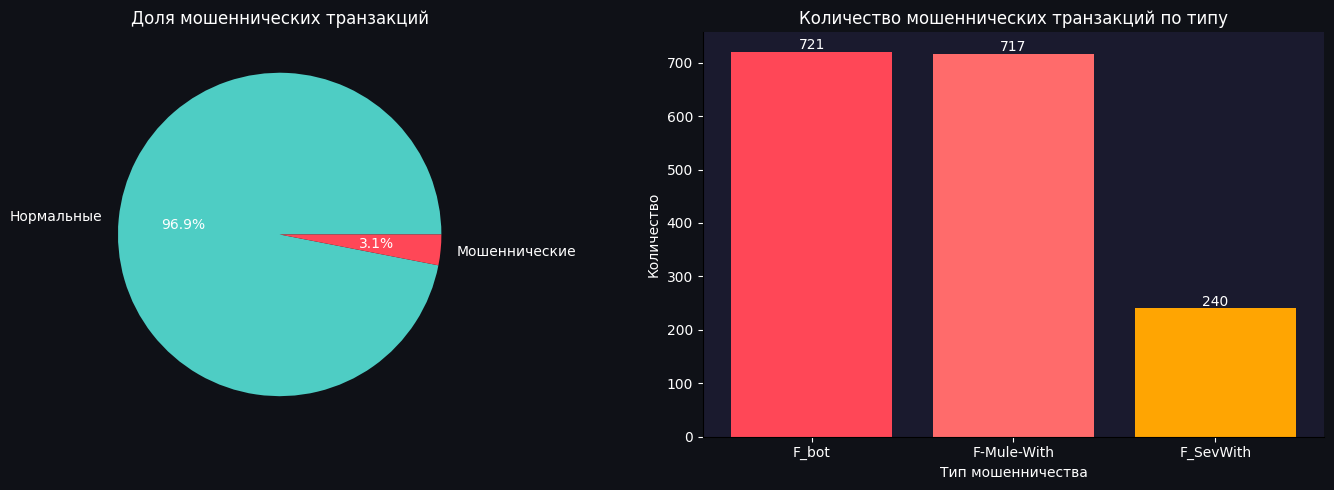

In [7]:
# Общая статистика
fraud = df[df['is_fraud']==1].copy()
normal = df[df['is_fraud']==0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
label_counts = df['label'].value_counts()
fraud_total = label_counts[label_counts.index.str.startswith('F')].sum()
normal_total = label_counts[~label_counts.index.str.startswith('F')].sum()
axes[0].pie([normal_total, fraud_total],
            labels=['Нормальные', 'Мошеннические'],
            autopct='%1.1f%%', colors=['#4ecdc4','#ff4757'],
            textprops={'color':'white'})
axes[0].set_title('Доля мошеннических транзакций')

# Bar by type
fraud_counts = fraud['label'].value_counts()
bars = axes[1].bar(fraud_counts.index, fraud_counts.values,
                   color=['#ff4757','#ff6b6b','#ffa502'])
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(int(bar.get_height())), ha='center', color='white')
axes[1].set_title('Количество мошеннических транзакций по типу')
axes[1].set_xlabel('Тип мошенничества')
axes[1].set_ylabel('Количество')
for sp in ['top','right']: axes[1].spines[sp].set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
print(df.shape)
print(df['label'].value_counts())
print(df.head(2))

(54848, 25)
label
N_Reg_RC       28312
N-RegDep       12867
N-RegC2C        7484
N_RegWith       4064
F_bot            721
F-Mule-With      717
N_Reg_Merch      443
F_SevWith        240
Name: count, dtype: int64
      label    sender_id  receiver_id  sender_acc receiver_acc    amount  \
0  N-RegC2C    PN_EU_3_4  PN_EU_0_883    EUAcc3_4   EUAcc0_883  68897.74   
1  N-RegC2C  PN_EU_1_139  PN_EU_0_754  EUAcc1_139   EUAcc0_754  68945.47   

  tx_type status sender_bal_before sender_bal_after  ... f4  \
0     Ind     SU      100000000.00      99930413.28  ...      
1     Ind     SU      100000000.00      99930365.08  ...      

             ts_sender          ts_receiver sender_acc2 srv1 srv2  \
0  01/06/2011 00:09:01  01/06/2011 00:09:01    EUAcc3_4             
1  01/06/2011 00:15:23  01/06/2011 00:15:23  EUAcc1_139             

           tx_time          sender_type receiver_type is_fraud  
0    C2C201161.099  01/06/2011 00:09:01            EU        0  
1  C2C201161.01515  01/06/2011 

In [9]:
# Разбивка по типам мошенничества
bot = fraud[fraud['label']=='F_bot'].copy()
mule = fraud[fraud['label']=='F-Mule-With'].copy()
sev = fraud[fraud['label']=='F_SevWith'].copy()

print("=== F_bot (Ботнет — переводы EU→Мул) ===")
print(f"  Транзакций: {len(bot)}")
print(f"  Уникальных отправителей (жертвы): {bot['sender_id'].nunique()}")
print(f"  Уникальных получателей (мулы): {bot['receiver_id'].nunique()}")
print(f"  Типы операций: {bot['tx_type'].unique()}")

print()
print("=== F-Mule-With (Мул — снятие денег) ===")
print(f"  Транзакций: {len(mule)}")
print(f"  Уникальных отправителей (мулы): {mule['sender_id'].nunique()}")
print(f"  Уникальных получателей (ретейлеры): {mule['receiver_id'].nunique()}")
print(f"  Типы операций: {mule['tx_type'].unique()}")

print()
print("=== F_SevWith (Кража телефона — серия снятий) ===")
print(f"  Транзакций: {len(sev)}")
print(f"  Уникальных отправителей (жертвы): {sev['sender_id'].nunique()}")
print(f"  Уникальных получателей (ретейлеры): {sev['receiver_id'].nunique()}")
print(f"  Транзакций на жертву: {len(sev)/sev['sender_id'].nunique():.1f} в среднем")


=== F_bot (Ботнет — переводы EU→Мул) ===
  Транзакций: 721
  Уникальных отправителей (жертвы): 39
  Уникальных получателей (мулы): 4
  Типы операций: <StringArray>
['Ind']
Length: 1, dtype: str

=== F-Mule-With (Мул — снятие денег) ===
  Транзакций: 717
  Уникальных отправителей (мулы): 4
  Уникальных получателей (ретейлеры): 6
  Типы операций: <StringArray>
['Wl']
Length: 1, dtype: str

=== F_SevWith (Кража телефона — серия снятий) ===
  Транзакций: 240
  Уникальных отправителей (жертвы): 60
  Уникальных получателей (ретейлеры): 6
  Транзакций на жертву: 4.0 в среднем


## 3. Схема 1: Мобильный ботнет
**Описание:** Устройства пользователей заражены мобильным ботнетом. Вредоносное ПО выполняет автоматические переводы (тип `Ind`) с аккаунтов жертв на аккаунты мул-пользователей. После накопления денег на мул-аккаунтах, мулы снимают наличные через ретейлеров (тип `Wl`).
**Признаки:**
- Множество уникальных отправителей → один получатель (звездообразный граф)
- Транзакции F_bot и F-Mule-With связаны: получатели F_bot == отправители F-Mule-With
- Всё происходит в короткий временной интервал


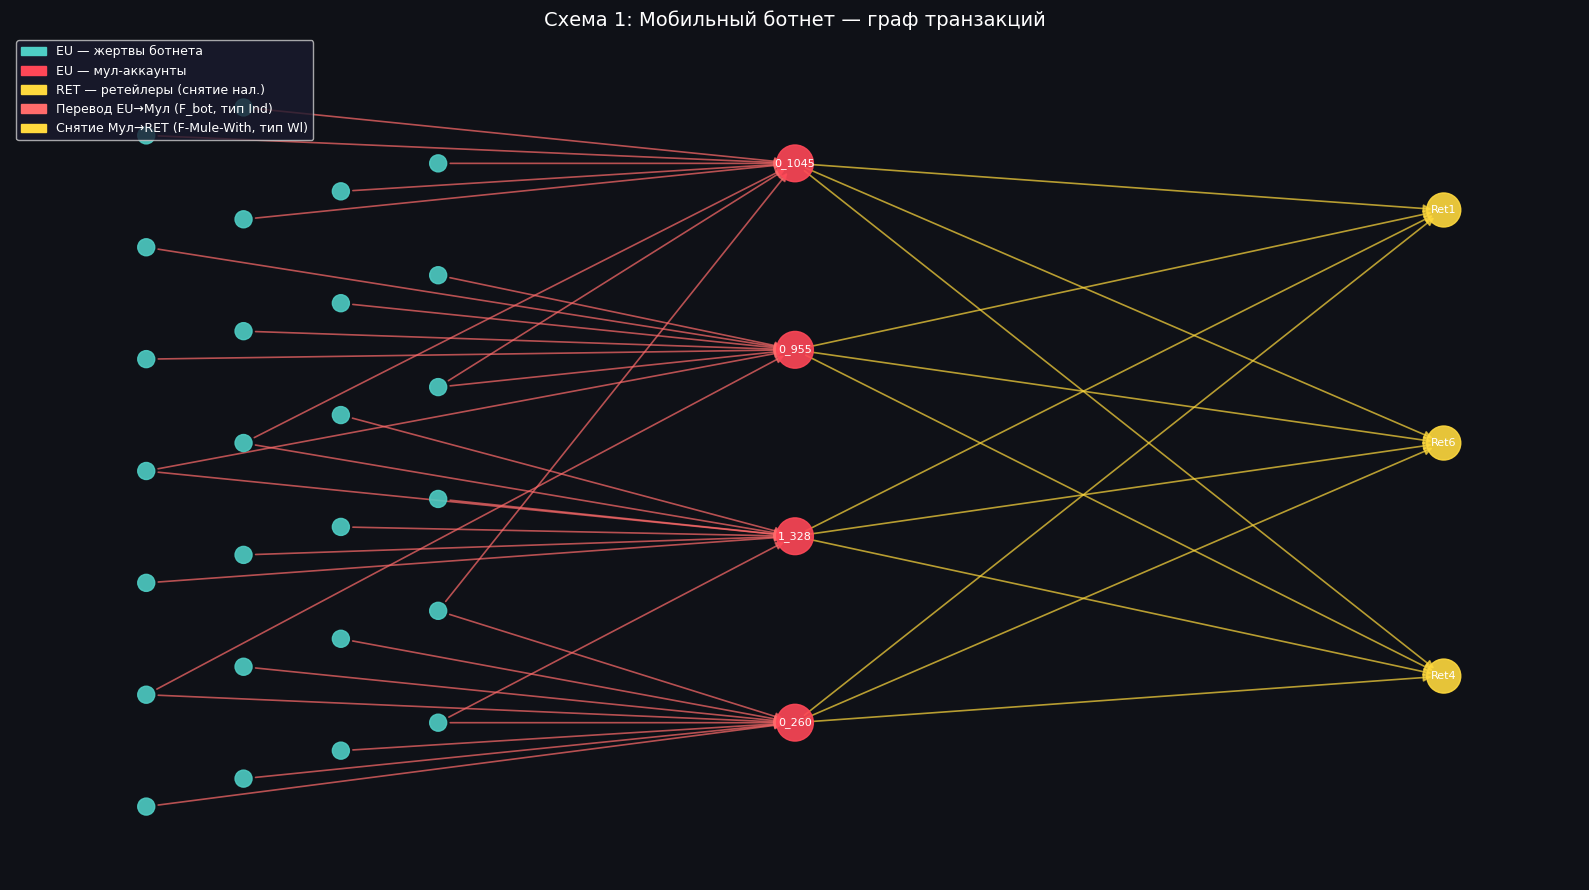

Узлов в графе: 33
Рёбер в графе: 44
Входящая степень мул-узлов:
  PN_EU_0_260: in=8, out=3
  PN_EU_1_328: in=8, out=3
  PN_EU_0_955: in=8, out=3
  PN_EU_0_1045: in=8, out=3


In [10]:
# Граф ботнета + снятий (Plotly-style через matplotlib)
mule_nodes = list(mule['sender_id'].unique())  # Это же получатели ботнет-переводов
ret_nodes_bot = list(mule['receiver_id'].value_counts().head(3).index)

G_bot = nx.DiGraph()

# Ботнет-переводы: жертва → мул
for mule_node in mule_nodes[:4]:
    senders = bot[bot['receiver_id']==mule_node]['sender_id'].unique()[:8]
    for s in senders:
        G_bot.add_edge(s, mule_node, etype='bot')

# Снятие: мул → ретейлер
for mule_node in mule_nodes[:4]:
    for r in ret_nodes_bot:
        if not G_bot.has_edge(mule_node, r):
            G_bot.add_edge(mule_node, r, etype='mule')

# Позиции
pos_bot = {}
all_victims = [n for n in G_bot.nodes() if n not in mule_nodes and n not in ret_nodes_bot]
for i, n in enumerate(all_victims):
    pos_bot[n] = (-4 + (i % 4)*0.6, i * 0.3 - len(all_victims)*0.15)
for i, n in enumerate(mule_nodes[:4]):
    pos_bot[n] = (0, i * 2 - 3)
for i, n in enumerate(ret_nodes_bot):
    pos_bot[n] = (4, i * 2.5 - 2.5)
for n in G_bot.nodes():
    if n not in pos_bot:
        pos_bot[n] = (0, 0)

fig, ax = plt.subplots(figsize=(16, 9))
node_colors = ['#4ecdc4' if n in all_victims else ('#ff4757' if n in mule_nodes else '#ffd93d')
               for n in G_bot.nodes()]
node_sizes = [150 if n in all_victims else (700 if n in mule_nodes else 600)
              for n in G_bot.nodes()]
edge_colors = ['#ff6b6b' if G_bot[u][v]['etype']=='bot' else '#ffd93d'
               for u, v in G_bot.edges()]

nx.draw_networkx_nodes(G_bot, pos_bot, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_bot, pos_bot, ax=ax, edge_color=edge_colors, arrows=True,
                       arrowsize=12, width=1.2, alpha=0.7)
label_dict = {n: n.replace('PN_EU_','').replace('PN_','') 
              for n in list(mule_nodes[:4]) + list(ret_nodes_bot)}
nx.draw_networkx_labels(G_bot, pos_bot, labels=label_dict, ax=ax, font_color='white', font_size=8)

legend = [
    mpatches.Patch(color='#4ecdc4', label='EU — жертвы ботнета'),
    mpatches.Patch(color='#ff4757', label='EU — мул-аккаунты'),
    mpatches.Patch(color='#ffd93d', label='RET — ретейлеры (снятие нал.)'),
    mpatches.Patch(color='#ff6b6b', label='Перевод EU→Мул (F_bot, тип Ind)'),
    mpatches.Patch(color='#ffd93d', label='Снятие Мул→RET (F-Mule-With, тип Wl)'),
]
ax.legend(handles=legend, loc='upper left', facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.set_title('Схема 1: Мобильный ботнет — граф транзакций', color='white', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Узлов в графе: {G_bot.number_of_nodes()}")
print(f"Рёбер в графе: {G_bot.number_of_edges()}")
print(f"Входящая степень мул-узлов:")
for m in mule_nodes[:4]:
    print(f"  {m}: in={G_bot.in_degree(m)}, out={G_bot.out_degree(m)}")


## 4. Схема 2: Кража мобильного телефона
**Описание:** После кражи телефона злоумышленник получает доступ к мобильному кошельку жертвы. Он быстро совершает несколько операций снятия наличных (`Wl`) через разных агентов-ретейлеров, чтобы вывести средства до блокировки аккаунта.
**Признаки:**
- Один отправитель (жертва) → несколько ретейлеров
- Короткий временной интервал между снятиями (минуты)
- Снятие через несколько ретейлеров подряд (diversification)
- Резкое падение баланса до нуля


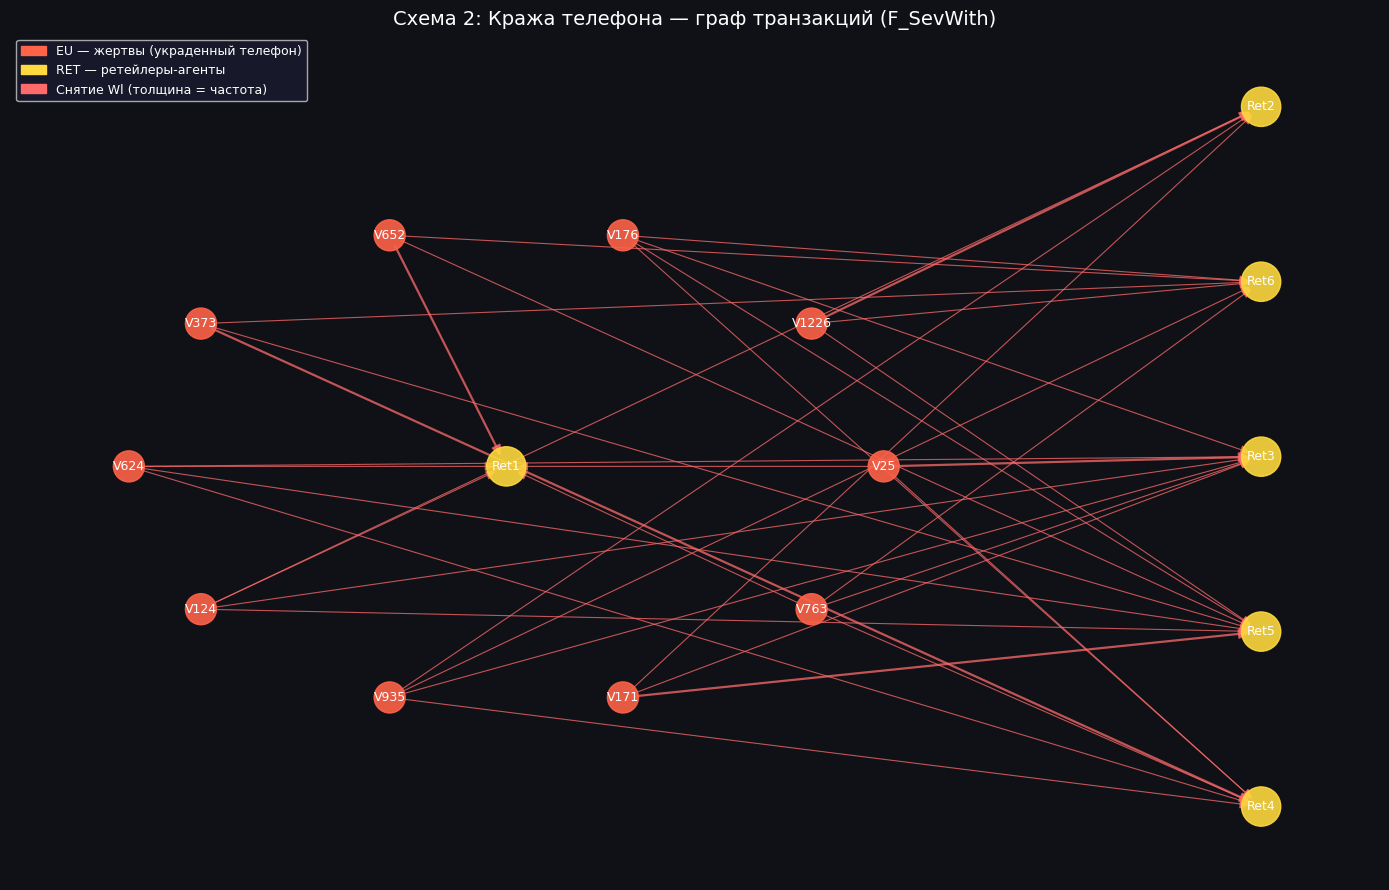

Узлов в графе: 16
Рёбер: 35

Исходящая степень вершин-жертв (кол-во разных ретейлеров):
  PN_EU_0_25: 3 ретейлеров, всего снятий: 4
  PN_EU_0_1226: 3 ретейлеров, всего снятий: 4
  PN_EU_0_176: 4 ретейлеров, всего снятий: 4
  PN_EU_0_652: 3 ретейлеров, всего снятий: 4
  PN_EU_0_373: 3 ретейлеров, всего снятий: 4


In [11]:
# Граф кражи телефона
victims_sev = list(sev['sender_id'].value_counts().head(10).index)
ret_nodes_sev = list(sev['receiver_id'].value_counts().head(5).index)

G_sev = nx.DiGraph()
for v in victims_sev:
    rets = sev[sev['sender_id']==v]['receiver_id'].unique()
    for r in rets:
        cnt = len(sev[(sev['sender_id']==v) & (sev['receiver_id']==r)])
        G_sev.add_edge(v, r, weight=cnt)

pos_sev = {}
for i, n in enumerate(victims_sev):
    angle = 2 * np.pi * i / len(victims_sev)
    pos_sev[n] = (np.cos(angle)*2.5, np.sin(angle)*2.5)
for i, n in enumerate(ret_nodes_sev):
    pos_sev[n] = (5, i*1.8 - 3.5)
for n in G_sev.nodes():
    if n not in pos_sev:
        pos_sev[n] = (0, 0)

fig, ax = plt.subplots(figsize=(14, 9))
node_colors_sev = ['#ff6348' if n in victims_sev else '#ffd93d' for n in G_sev.nodes()]
node_sizes_sev = [500 if n in victims_sev else 800 for n in G_sev.nodes()]
edge_widths = [G_sev[u][v]['weight']*0.8 for u,v in G_sev.edges()]
nx.draw_networkx_nodes(G_sev, pos_sev, ax=ax, node_color=node_colors_sev,
                       node_size=node_sizes_sev, alpha=0.9)
nx.draw_networkx_edges(G_sev, pos_sev, ax=ax, edge_color='#ff6b6b', arrows=True,
                       arrowsize=14, width=edge_widths, alpha=0.75)
labels_sev = {n: n.replace('PN_EU_0_','V').replace('PN_EU_1_','V').replace('PN_Ret','Ret')
              for n in G_sev.nodes()}
nx.draw_networkx_labels(G_sev, pos_sev, labels=labels_sev, ax=ax, font_color='white', font_size=9)

legend_sev = [
    mpatches.Patch(color='#ff6348', label='EU — жертвы (украденный телефон)'),
    mpatches.Patch(color='#ffd93d', label='RET — ретейлеры-агенты'),
    mpatches.Patch(color='#ff6b6b', label='Снятие Wl (толщина = частота)'),
]
ax.legend(handles=legend_sev, loc='upper left', facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.set_title('Схема 2: Кража телефона — граф транзакций (F_SevWith)', color='white', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Узлов в графе: {G_sev.number_of_nodes()}")
print(f"Рёбер: {G_sev.number_of_edges()}")
print(f"\nИсходящая степень вершин-жертв (кол-во разных ретейлеров):")
for v in victims_sev[:5]:
    print(f"  {v}: {G_sev.out_degree(v)} ретейлеров, "
          f"всего снятий: {len(sev[sev['sender_id']==v])}")


## 5. Временной анализ — подтверждение паттернов

In [12]:
# Анализ времени снятий для одной жертвы кражи
# Выбираем жертву с наибольшим числом транзакций
top_victim = sev['sender_id'].value_counts().idxmax()
victim_txs = sev[sev['sender_id']==top_victim].copy()
victim_txs['ts'] = pd.to_datetime(victim_txs['ts_sender'], dayfirst=True, errors='coerce')
victim_txs = victim_txs.sort_values('ts')

print(f"Жертва: {top_victim}")
print(f"Транзакций: {len(victim_txs)}")
print(f"Временной диапазон: {victim_txs['ts'].min()} — {victim_txs['ts'].max()}")
duration = (victim_txs['ts'].max() - victim_txs['ts'].min()).total_seconds() / 60
print(f"Длительность атаки: {duration:.1f} минут")
print()
print(victim_txs[['ts','receiver_id','amount','tx_type']].to_string(index=False))


Жертва: PN_EU_0_25
Транзакций: 4
Временной диапазон: 2011-06-05 22:24:34 — 2011-06-05 22:35:35
Длительность атаки: 11.0 минут

                 ts receiver_id   amount tx_type
2011-06-05 22:24:34     PN_Ret3 50864.49      Wl
2011-06-05 22:27:25     PN_Ret1  1190.00      Wl
2011-06-05 22:31:37     PN_Ret3 32478.57      Wl
2011-06-05 22:35:35     PN_Ret4 17765.43      Wl


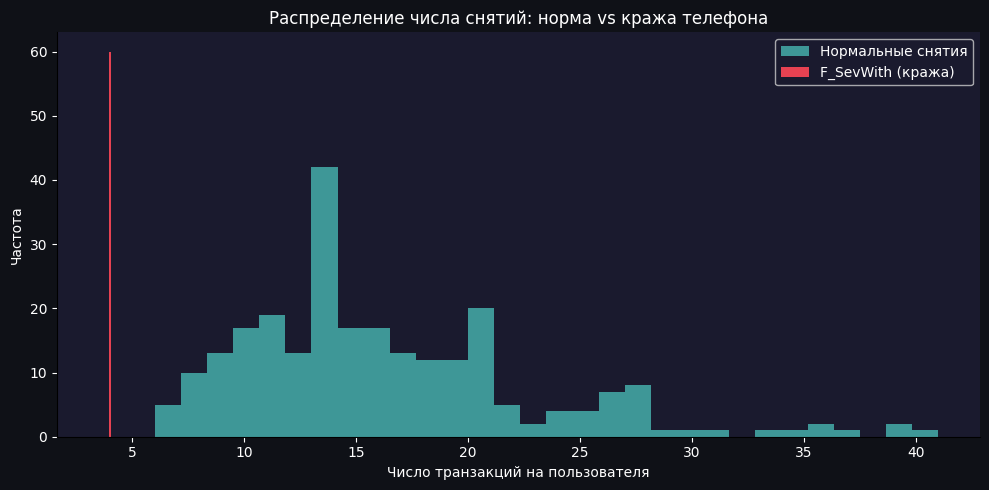

Среднее F_SevWith: 4.00
Среднее N_RegWith: 16.19


In [13]:
# Сравнение числа снятий в единицу времени: F_SevWith vs N_RegWith
sev_counts = sev.groupby('sender_id').size().reset_index(name='n_txs')
norm_with = df[df['label']=='N_RegWith']
norm_counts = norm_with.groupby('sender_id').size().reset_index(name='n_txs')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(norm_counts['n_txs'], bins=30, alpha=0.7, color='#4ecdc4', label='Нормальные снятия')
ax.hist(sev_counts['n_txs'], bins=15, alpha=0.9, color='#ff4757', label='F_SevWith (кража)')
ax.set_xlabel('Число транзакций на пользователя')
ax.set_ylabel('Частота')
ax.set_title('Распределение числа снятий: норма vs кража телефона')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Среднее F_SevWith: {sev_counts['n_txs'].mean():.2f}")
print(f"Среднее N_RegWith: {norm_counts['n_txs'].mean():.2f}")


## 6. Интерактивная визуализация (Pyvis)
> **Примечание:** Для запуска интерактивной визуализации необходима установка библиотеки `pyvis`.  
> Установка: `pip install pyvis`


In [ ]:
# Интерактивная визуализация с Pyvis
# Если pyvis не установлен, этот блок пропускается

try:
    from pyvis.network import Network

    net = Network(height='600px', width='100%', bgcolor='#0f1117',
                  font_color='white', directed=True)

    mule_list = list(mule['sender_id'].unique())[:4]
    ret_list = list(mule['receiver_id'].value_counts().head(3).index)

    for mule_node in mule_list:
        senders = bot[bot['receiver_id']==mule_node]['sender_id'].unique()[:6]
        for s in senders:
            net.add_node(s, label=s.replace('PN_EU_','EU'), color='#4ecdc4',
                         size=10, title='Жертва ботнета')
            net.add_node(mule_node, label=mule_node.replace('PN_EU_','МУЛ:'),
                         color='#ff4757', size=25, title='Мул-аккаунт')
            net.add_edge(s, mule_node, color='#ff6b6b', title='F_bot (Ind)')
        for r in ret_list[:2]:
            net.add_node(r, label=r.replace('PN_',''), color='#ffd93d',
                         size=20, title='Ретейлер (агент)')
            net.add_edge(mule_node, r, color='#ffd93d', title='F-Mule-With (Wl)')

    net.set_options('''
    {
      "physics": {
        "barnesHut": {"gravitationalConstant": -8000, "springLength": 150},
        "stabilization": {"iterations": 100}
      }
    }''')
    net.show('botnet_graph.html', notebook=False)
    print("Интерактивный граф сохранён в botnet_graph.html")
except ImportError:
    print("pyvis не установлен. Установите: pip install pyvis")
    print("Статическая визуализация показана выше.")


botnet_graph.html


AttributeError: 'NoneType' object has no attribute 'render'

## 7. Выводы

### Схема мошенничества №1: Мобильный ботнет

**Структура:**  
`EU (жертвы) → EU (мул-аккаунты) → RET (ретейлеры)`

**Описание:**  
Мобильный ботнет заражает устройства пользователей (`EU`). Вредоносная программа без ведома жертвы совершает переводы (тип `Ind`) на аккаунты мул-пользователей. После накопления средств мулы снимают деньги наличными через агентов-ретейлеров (тип `Wl`).

**Признаки на графе:**
- Звездообразная топология: ~39 жертв → 1 мул-аккаунт
- Мул-аккаунты одновременно являются отправителями в `F-Mule-With`
- Высокая входящая степень у мул-узлов
- Все транзакции — тип `Ind` (P2P) и `Wl` (снятие)

---

### Схема мошенничества №2: Кража мобильного телефона

**Структура:**  
`EU (жертва, 1 узел) → RET (несколько ретейлеров)`

**Описание:**  
После кражи телефона злоумышленник получает доступ к мобильному кошельку. Чтобы успеть вывести деньги до блокировки аккаунта, он быстро совершает несколько снятий через разных агентов-ретейлеров (диверсификация).

**Признаки на графе:**
- 1 отправитель → несколько ретейлеров (биопартитный граф «звезда»)
- Короткий временной интервал между транзакциями (несколько минут)
- Множественные `Wl` от одного пользователя за одну сессию
- Среднее число снятий на жертву значительно выше нормы
